In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter1d
from sunpy.coordinates import Helioprojective, SphericalScreen, propagate_with_solar_surface
from astropy.wcs import WCS
from gaussian_fit import fit_gaussian, fit_double_gaussian
import matplotlib.ticker as ticker
from matplotlib.path import Path

In [10]:
for i in range(6):
    os.makedirs(f'C:\\Learning\\PHD1st\\magnetic_reconnecion\\data\\BBSO\\ja3\\2024\\06\\fig\\b0{i*20}_fig', exist_ok=True)

In [14]:
import shutil
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\BBSO\ja3\2024\06\18\24jun18_vissr\bbso_har100*.fts')
for i in range(len(file_list)):
    shutil.move(file_list[i], r'C:\Learning\PHD1st\magnetic_reconnecion\data\BBSO\ja3\2024\06\18\r100')

In [14]:
map304=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\304\aia.lev1_euv_12s.2024-06-18T210043Z.304.image_lev1.fits')
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map304.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map304.coordinate_frame)
smap_304=map304.submap(bottom_left,top_right=top_right)

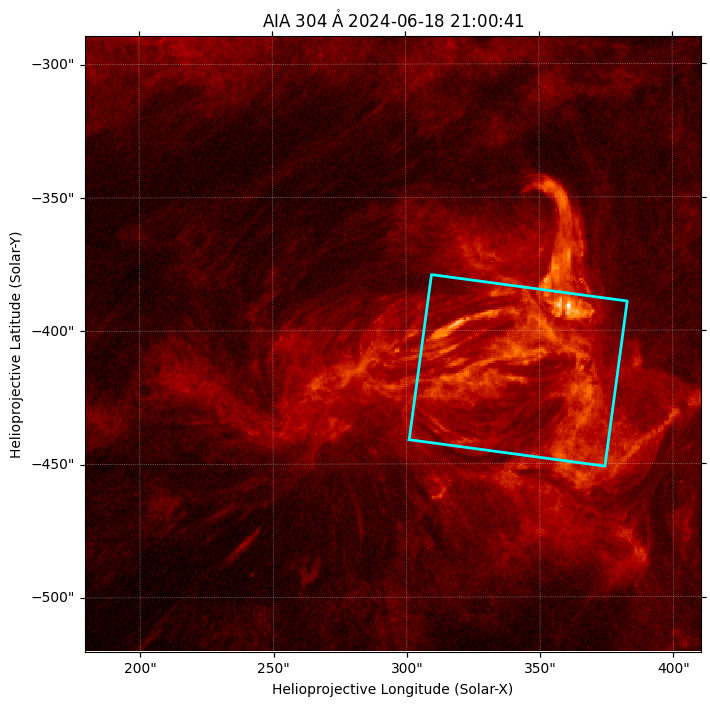

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord

# =========================
# GST header information
# =========================
xc = 342.0          # arcsec
yc = -415.0         # arcsec

nx = 2555
ny = 2155

scale_x = 0.029     # arcsec / pixel
scale_y = 0.029

crota1 = -7.815578   # degree, CROTA1

# GST field of view
width  = nx * scale_x
height = ny * scale_y

# half width / height
dx = width / 2
dy = height / 2


# =========================
# Four corners before rotation
# =========================
corners = np.array([
    [-dx, -dy],
    [ dx, -dy],
    [ dx,  dy],
    [-dx,  dy]
])


# =========================
# Rotate
# =========================
theta = np.deg2rad(crota1)

R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

corners_rot = corners @ R.T

# translate to GST FOV center
x = corners_rot[:, 0] + xc
y = corners_rot[:, 1] + yc

# close the rectangle
x = np.append(x, x[0])
y = np.append(y, y[0])


# =========================
# Plot on your AIA 304 map
# =========================
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection=smap_304)

smap_304.plot(axes=ax)

gst_fov = SkyCoord(
    Tx=x * u.arcsec,
    Ty=y * u.arcsec,
    frame=smap_304.coordinate_frame
)

ax.plot_coord(
    gst_fov,
    color='cyan',
    linewidth=2
)

plt.show()

In [14]:
print(rsm[0].header['DATE-OBS'])

2024-06-18


In [ ]:
from scipy.ndimage import rotate
name_list=['r020','r040','r060','r080','r100','b020','b040','b060','b080','b100']
for k in range(len(name_list)):
    file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\BBSO\ja3\2024\06\18\\' + name_list[k] + '\\*.fts')
    for i in range(len(file_list)):
        rsm=fits.open(file_list[i])
        rotate_angle=-rsm[0].header['CROTA1']
        data_rot=rotate(rsm[0].data, rotate_angle, reshape=True)
        plt.title(f"{rsm[0].header['DATE-OBS']} {rsm[0].header['TIME-OBS']}")
        plt.imshow(data_rot, cmap='afmhot', origin='lower')
        plt.savefig(f"C:\\Learning\\PHD1st\\magnetic_reconnecion\\data\\BBSO\\ja3\\2024\\06\\fig\\{name_list[k]}_fig\\{i:02d}.png", dpi=300)
        plt.close()

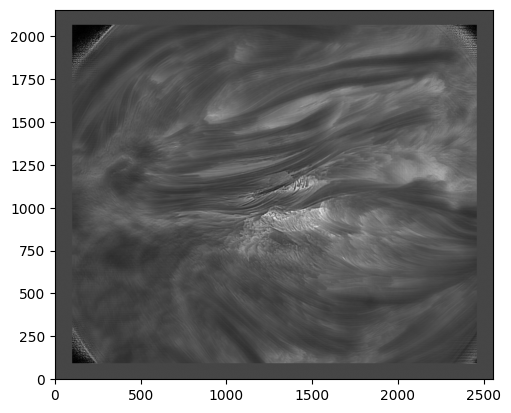

In [8]:
rsm=fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\BBSO\ja3\2024\06\18\24jun18_vissr\bbso_har000_vissr_20240618_210034.fts')
plt.imshow(rsm[0].data, cmap='gray', origin='lower')

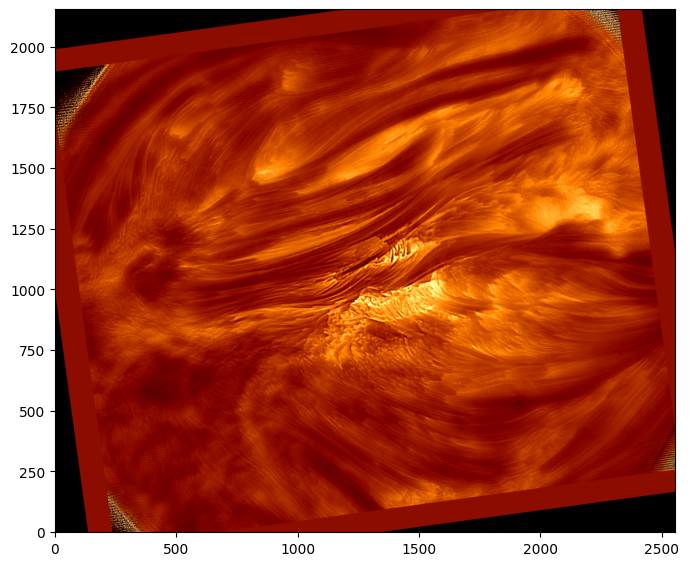

In [16]:
from scipy.ndimage import rotate
import matplotlib.pyplot as plt

angle = -7.815578

img_rot = rotate(rsm[0].data, angle, reshape=False)

plt.figure(figsize=(8, 8))
plt.imshow(img_rot, origin='lower', cmap='afmhot')
plt.show()

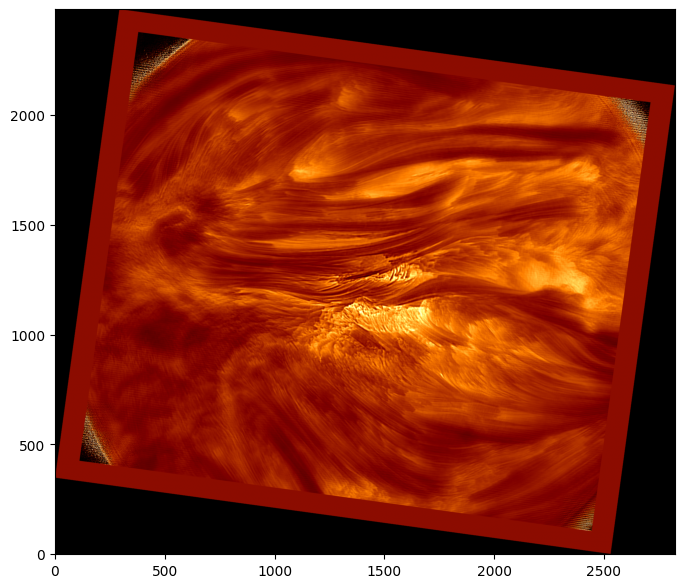

In [18]:
from scipy.ndimage import rotate
import matplotlib.pyplot as plt

angle = 7.815578

img_rot = rotate(rsm[0].data, angle, reshape=True)

plt.figure(figsize=(8, 8))
plt.imshow(img_rot, origin='lower', cmap='afmhot')
plt.show()

In [7]:
from pathlib import Path

folder = Path(r"C:\Learning\PHD1st\magnetic_reconnecion\data\BBSO\ja3\2024\06\18\r000_fig")
for p in folder.rglob("*.png"):
    if p.is_file() and len(p.stem) == 1 and p.stem.isdigit():
        target = p.with_name(f"{int(p.stem):02d}{p.suffix}")
        if not target.exists():
            p.rename(target)